<a href="https://colab.research.google.com/github/SauSauN/Data_Nelly_Academic_Project/blob/main/Data_viz_tp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1) Prise en main du dataset

### 1. Charger le dataset.

In [3]:
df = sns.load_dataset("titanic")

### 2. Afficher les 10 premières lignes.

In [4]:
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


### 3. Donner la dimension du dataset.

In [5]:
df.shape

(891, 15)

### 4. Lister l’ensemble des colonnes.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


### 5. Identifier la nature de chaque variable.

In [7]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 6. Identifier explicitement la variable cible.

In [8]:
y = df["survived"]
print("Variable cible (y) :")
print(y.head())

Variable cible (y) :
0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64


# Questions

### 1. Quelle est la structure générale du dataset?
### 2. Quelles variables sont numériques?
### 3. Quelles variables sont catégorielles?
### 4. Pourquoi la variable survived peut-elle être considérée comme une cible de classification?

# 2) Vérification de la variable cible et des classes

### 1. Donner le nombre exact de classes.

In [9]:
nombre_classes = df['pclass'].nunique()
print("Nombre exact de classes :", nombre_classes)

Nombre exact de classes : 3


### 2. Donner l’effectif exact de chaque classe.

In [10]:
effectifs_classes = df['pclass'].value_counts().sort_index()
print("\nEffectif de chaque classe :\n", effectifs_classes)


Effectif de chaque classe :
 pclass
1    216
2    184
3    491
Name: count, dtype: int64


### 3. Calculer la proportion de chaque classe.

In [11]:
proportions_classes = df['pclass'].value_counts(normalize=True).sort_index()
print("\nProportion de chaque classe :\n", proportions_classes)


Proportion de chaque classe :
 pclass
1    0.242424
2    0.206510
3    0.551066
Name: proportion, dtype: float64


### 4. Produire une visualisation adaptée à la distribution des classes.

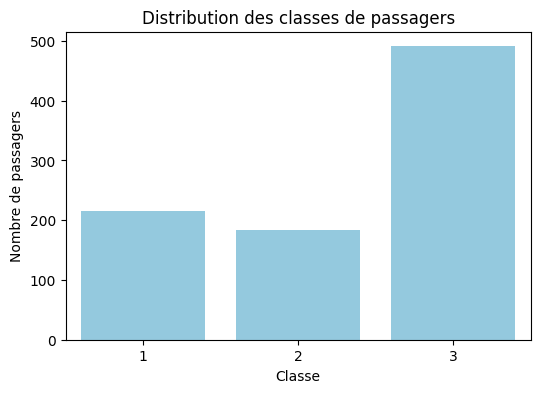

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='pclass', data=df, color='skyblue')
plt.title("Distribution des classes de passagers")
plt.xlabel("Classe")
plt.ylabel("Nombre de passagers")
plt.show()

# Questions

### 1. Combien de classes contient le dataset?
### 2. Les classes sont-elles équilibrées?
### 3. Pourquoi cette vérification est-elle indispensable avant toute phase de modélisation?
### 4. Quelles conséquences un déséquilibre de classes pourrait-il avoir sur un futur classifieur?

# 3) Qualité des données

### 1. Quantifier les valeurs manquantes colonne par colonne.

In [13]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


### 2. Vérifier la présence éventuelle de doublons.

In [14]:
doublons = df.duplicated().sum()
print("\nNombre de doublons :", doublons)


Nombre de doublons : 107


### 3. Identifier les colonnes problématiques et expliciter la nature de chaque problème.

| Colonne         | Problème                            | Nature du problème                               |
| --------------- | ----------------------------------- | ------------------------------------------------ |
| `age`           | valeurs manquantes                  | Certaines entrées n’ont pas d’âge                |
| `deck`          | valeurs manquantes massives         | Beaucoup de passagers n’ont pas de deck attribué |
| `embarked`      | valeurs manquantes ou erreurs       | Peut contenir `NaN` ou codes incorrects          |
| Autres colonnes | potentiels doublons ou incohérences | À vérifier selon dataset complet                 |


### 4. Choisir, justifier et appliquer une stratégie de traitement des données manquantes.

In [15]:
# Imputation age par médiane par groupe 'sex'
df['age'] = df.groupby('sex')['age'].transform(lambda x: x.fillna(x.median()))

# Imputation embarked et embark_town par mode
mode_embarked = df['embarked'].mode()[0]
df['embarked'] = df['embarked'].fillna(mode_embarked)

mode_embark_town = df['embark_town'].mode()[0]
df['embark_town'] = df['embark_town'].fillna(mode_embark_town)

# Suppression de la colonne deck
df = df.drop(columns=['deck'])

df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


### 5. Justifier précisément le traitement retenu.

| Colonne       | Traitement                   | Raison principale                                        |
| ------------- | ---------------------------- | -------------------------------------------------------- |
| `age`         | Imputation médiane par `sex` | Robustesse, préservation distribution, logique du groupe |
| `embarked`    | Imputation par mode          | Très peu de manquants, impact minime                     |
| `embark_town` | Imputation par mode          | Correspondance avec `embarked`, même raisonnement        |
| `deck`        | Suppression                  | Taux de manquants trop élevé, imputation risquée         |


# Questions

### 1. Quelles colonnes posent problème?
### 2. Pourquoi ces problèmes doivent-ils être traités avant toute analyse sérieuse?
### 3. En quoi le traitement choisi peut-il influencer les conclusions ultérieures?
### 4. Quel risque y aurait-il à ignorer cette étape?

# 4) Manipulation et transformation des données

### 1. Trier le dataset selon une variable numérique pertinente.

In [16]:
df_sorted = df.sort_values(by='fare', ascending=False)
df_sorted.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
679,1,1,male,36.0,0,1,512.3292,C,First,man,True,Cherbourg,yes,False
258,1,1,female,35.0,0,0,512.3292,C,First,woman,False,Cherbourg,yes,True
737,1,1,male,35.0,0,0,512.3292,C,First,man,True,Cherbourg,yes,True
88,1,1,female,23.0,3,2,263.0000,S,First,woman,False,Southampton,yes,False
438,0,1,male,64.0,1,4,263.0000,S,First,man,True,Southampton,no,False


### 2. Filtrer le dataset selon une condition que vous préciserez explicitement.

In [17]:
df_survived = df[df['survived'] == 1]
df_survived.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,Cherbourg,yes,False


### 3. Construire un tableau agrégé avec groupby selon la variable cible.

In [19]:
agg_survived = df.groupby('survived')[['age','fare']].mean()
agg_survived

,age,fare
survived,,
0,30.193989,22.117887
1,28.232953,48.395408


### 4. Construire un second tableau agrégé croisant la variable cible et le sexe.

In [20]:
agg_survived_sex = df.groupby(['survived','sex'])['pclass'].count().unstack()
agg_survived_sex

sex,female,male
survived,,
0,81,468
1,233,109


### 5. Créer une nouvelle variable dérivée à partir des mesures existantes.

In [21]:
df['family_size'] = df['sibsp'] + df['parch']
df[['sibsp','parch','family_size']].head(5)

,sibsp,parch,family_size
0,1,0,1
1,1,0,1
2,0,0,0
3,1,0,1
4,0,0,0


### 6. Interpréter l’intérêt analytique de cette nouvelle variable.



*   family_size mesure la taille de la famille à bord.

*   Intérêt : Permet d’étudier l’effet de la taille de la famille sur la survie.
Les passagers seuls ou avec une très grande famille peuvent avoir plus de risque de ne pas survivre.
Variable utile pour les modèles prédictifs : elle synthétise sibsp et parch en un seul indicateur pertinent.



# Questions

### 1. Quel est l’intérêt du premier tableau agrégé?
### 2. Que montre le second tableau agrégé?
### 3. La variable dérivée créée apporte-t-elle une information utile?
### 4. Pourquoi une transformation peut-elle enrichir l’analyse?

# 5) Analyse descriptive des variables

### 1. Produire les statistiques descriptives complètes des variables numériques.

In [22]:
df.describe()

,survived,pclass,age,sibsp,parch,fare,family_size
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.441268,0.523008,0.381594,32.204208,0.904602
std,0.486592,0.836071,13.018747,1.102743,0.806057,49.693429,1.613459
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,0.000000
50%,0.000000,3.000000,29.000000,0.000000,0.000000,14.454200,0.000000
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,1.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,10.000000


### 2. Représenter la distribution de age.

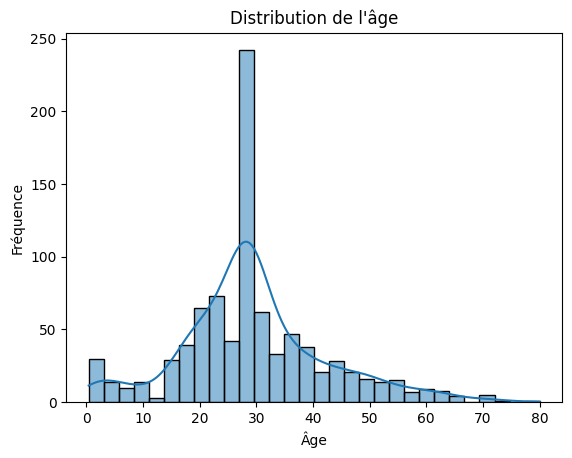

In [23]:
plt.figure()
sns.histplot(df['age'], kde=True)
plt.title("Distribution de l'âge")
plt.xlabel("Âge")
plt.ylabel("Fréquence")
plt.show()

### 3. Représenter la distribution de fare.

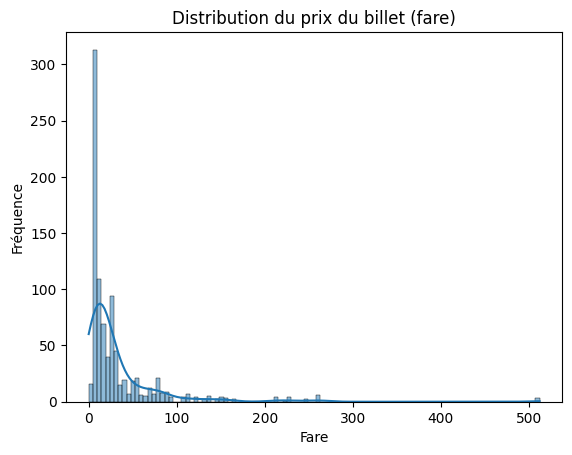

In [25]:
plt.figure()
sns.histplot(df['fare'], kde=True)
plt.title("Distribution du prix du billet (fare)")
plt.xlabel("Fare")
plt.ylabel("Fréquence")
plt.show()

### 4. Représenter la distribution d’une variable catégorielle pertinente.

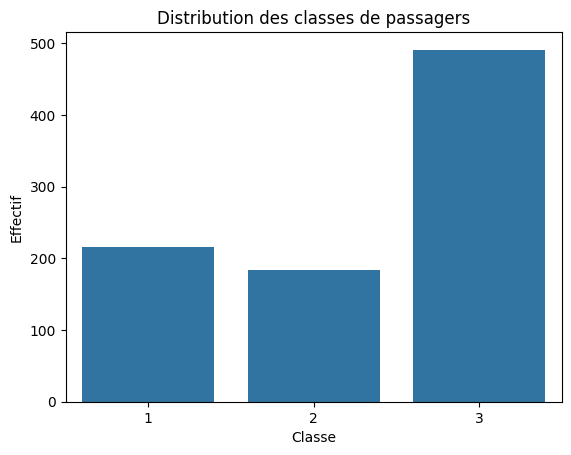

In [27]:
plt.figure()
sns.countplot(x='pclass', data=df)
plt.title("Distribution des classes de passagers")
plt.xlabel("Classe")
plt.ylabel("Effectif")
plt.show()

### 5. Interpréter les différences de structure observées entre ces variables.

1.   Variables numériques (age, fare)
*   age :
Distribution relativement étalée
Peu d’outliers
Structure "humaine" (centrée sur adultes)
*   fare :
Distribution très déséquilibrée
Forte présence d’outliers
Corrélée à la classe sociale



Donc :
*   age → variable biologique, distribution naturelle
*   fare → variable économique, distribution inégale
2.   Variable catégorielle (pclass)
*   Distribution discrète et déséquilibrée
*   Représente des groupes distincts (pas une continuité)

# Questions


### 1. Quelles variables numériques présentent la plus forte dispersion?
### 2. Observez-vous des asymétries marquées?  
### 3. Observez-vous des valeurs atypiques?  
### 4. Quelle représentation est la plus adaptée pour chaque variable étudiée? Pourquoi?

# 6) Comparaison entre classes

# Questions

### 1. Quelles variables semblent les plus discriminantes pour distinguer les deux classes?
### 2. Certains groupes paraissent-ils nettement séparés?
### 3. Certaines variables paraissent-elles plus informatives que d’autres?
### 4. En quoi ces comparaisons sont-elles utiles avant une classification?

# 7) Relations entre variables et séparabilité

# Questions


### 1. Quelles relations entre variables vous paraissent les plus marquées?
### 2. Certaines variables semblent-elles redondantes?
### 3. Les classes paraissent-elles visuellement séparables dans l’espace des variables?
### 4. La séparabilité est-elle nette?
### 5. Que montre la heatmap que les visualisations précédentes ne montrent pas directement?

# 8) Sélection raisonnée des variables

# Questions


### 1. Quelles variables vous paraissent les plus pertinentes pour la classification?
### 2. Quelles variables vous paraissent secondaires ou redondantes?
### 3. Quels risques y aurait-il à conserver toutes les variables sans réflexion?
### 4. Votre sélection repose-t-elle uniquement sur l’intuition visuelle? Pourquoi?

# 9) Préparation à une future modélisation

# Questions


### 1. Quelles étapes de prétraitement sont indispensables ici?
### 2. Quels traitements dépendraient du modèle choisi?
### 3. Quels biais ou erreurs méthodologiques faudrait-il éviter?
### 4. Le dataset paraît-il prêt à être modélisé immédiatement? Justifiez.

# 10) Discussion critique dans une perspective de machine learning

# Questions


### 1. Le dataset est-il exploitable pour une tâche de classification?
### 2. Quels sont ses points forts?
### 3. Quelles sont ses principales limites?
### 4. Quelles conclusions vous paraissent solides? Quelles conclusions restent plus prudentes?
### 5. Le dataset vous paraît-il favorable, moyennement favorable ou défavorable à une future modélisation? Justifiez.

# 3 Bonus